# Imports

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
import os





# Device

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Data

In [22]:
# ========== Define paths ==========
base = Path("cnn_dataset")
labels_csv = base / "labels.csv"
images_dir = base / "images"

In [23]:
# ========== Load the labels file ==========
labels_df = pd.read_csv(labels_csv)
print("Labels loaded:")
print(labels_df.head())
print(labels_df.info())

Labels loaded:
          filename  label
0  circle_0000.png      0
1  circle_0001.png      0
2  circle_0002.png      0
3  circle_0003.png      0
4  circle_0004.png      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  1800 non-null   object
 1   label     1800 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 28.3+ KB
None


In [24]:
# ========== Add full image paths ==========
labels_df["path"] = labels_df["filename"].apply(lambda f: images_dir / f)

In [25]:
# ========== Check for missing image files ==========
missing = [p for p in labels_df["path"] if not p.exists()]
if missing:
    print(f"Missing {len(missing)} image files.")
else:
    print("All image files exist.")

All image files exist.


In [26]:
# ========== Load raw images and labels ==========
images = []
labels = []

for _, row in labels_df.iterrows():
    img = Image.open(row["path"])  # load raw, no convert, no resize
    images.append(img)             # keep as PIL Image object
    labels.append(row["label"])

print("Raw data loaded successfully.")
print("Number of images:", len(images))
print("Number of labels:", len(labels))
print("Example image size:", images[0].size)
print("Example image mode:", images[0].mode) # Luminance (grayscale)

Raw data loaded successfully.
Number of images: 1800
Number of labels: 1800
Example image size: (32, 32)
Example image mode: L


In [27]:
# ========== Basic label info ==========
print("\nLabel distribution:")
print(pd.Series(labels).value_counts())
print("Unique labels:", np.unique(labels))



Label distribution:
0    600
1    600
2    600
Name: count, dtype: int64
Unique labels: [0 1 2]


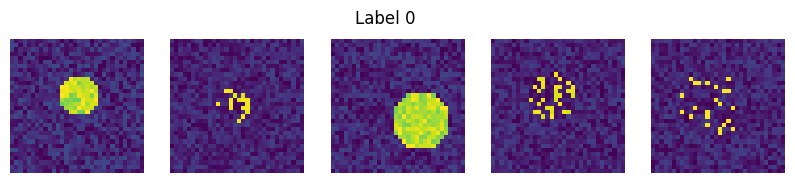

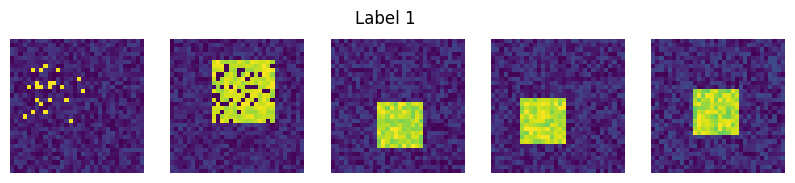

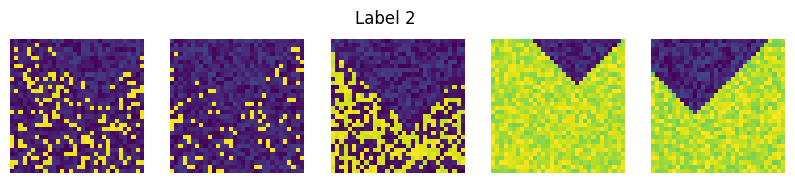

In [28]:
# ========== Quick visual sanity check ==========
unique_labels = np.unique(labels)

for label in unique_labels:
    # get indexes of the first 5 images with this label
    indices = [i for i, lbl in enumerate(labels) if lbl == label][:5]

    plt.figure(figsize=(10, 2))
    plt.suptitle(f"Label {label}")

    for i, idx in enumerate(indices):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[idx])
        plt.axis("off")

    plt.show()

# Clean data

In [29]:
# ========== Check for corrupted images ==========

bad_images = []

for path in labels_df["path"]:
    try:
        img = Image.open(path)
        img.verify()  # verify file integrity
    except (UnidentifiedImageError, OSError):
        bad_images.append(path)

if bad_images:
    print(f"Found {len(bad_images)} corrupted images.")
else:
    print("No corrupted images found.")

No corrupted images found.


In [30]:
# ========== Check image properties (mode and size) ==========

# Dictionaries to collect which files have which size/mode
size_groups = {}
mode_groups = {}

for path in labels_df["path"]:
    with Image.open(path) as img:
        size = img.size
        mode = img.mode

        size_groups.setdefault(size, []).append(path.name)
        mode_groups.setdefault(mode, []).append(path.name)

# ----- Summary -----
print("=== Image Sizes Summary ===")
for size, files in size_groups.items():
    print(f"Size {size}: {len(files)} images")
    if len(files) < 10:  # show small groups that are unusual
        print("  ->", files[:5], "...")

print("\n=== Image Modes Summary ===")
for mode, files in mode_groups.items():
    print(f"Mode '{mode}': {len(files)} images")
    if len(files) < 10:
        print("  ->", files[:5], "...")

=== Image Sizes Summary ===
Size (32, 32): 1800 images

=== Image Modes Summary ===
Mode 'L': 1800 images


In [31]:
# ========== Check for duplicate filenames or rows ==========
duplicates = labels_df[labels_df.duplicated(subset=["filename"])]
if not duplicates.empty:
    print("Duplicate filenames found:")
    print(duplicates)
else:
    print("No duplicate filenames.")

No duplicate filenames.


# Spilt data

In [32]:
# ---- Split: 70% train, 30% temp (val + test) ----
train_df, temp_df = train_test_split(
    labels_df,
    test_size=0.30,
    stratify=labels_df["label"],   # keep label balance
    random_state=42
)

# ---- Split: 15% val, 15% test ----
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,                 # half of 30% = 15% each
    stratify=temp_df["label"],
    random_state=42
)

# ---- Check sizes ----
print(f"Train set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Test set: {len(test_df)}")

# ---- Quick look at the first few rows ----
print(train_df.head())

Train set: 1260
Validation set: 270
Test set: 270
               filename  label                                  path
380     circle_0380.png      0    cnn_dataset\images\circle_0380.png
1511  triangle_0311.png      2  cnn_dataset\images\triangle_0311.png
1337  triangle_0137.png      2  cnn_dataset\images\triangle_0137.png
23      circle_0023.png      0    cnn_dataset\images\circle_0023.png
1120    square_0520.png      1    cnn_dataset\images\square_0520.png


# Preprocess data

In [33]:
transform = transforms.Compose([
    # No need to resize since all images are already 32x32

    transforms.ToTensor(),
    # Converts PIL grayscale image ('L') to tensor of shape (1, 32, 32)
    # and scales pixel values from [0, 255] → [0.0, 1.0]

    transforms.Normalize((0.5,), (0.5,))
    # Normalizes the single channel:
    # new_value = (value - 0.5) / 0.5 → maps [0,1] → [-1,1]
    # (0.5,) means one mean value for the single grayscale channel
])

# Custom dataset Class

In [34]:
# ----- Custom dataset class -----
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "label"]
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        return image, label

# ----- Create datasets for each split -----
train_dataset = CustomImageDataset(train_df, transform=transform)
val_dataset   = CustomImageDataset(val_df,   transform=transform)
test_dataset  = CustomImageDataset(test_df,  transform=transform)

# Parameters

In [35]:
lr = 1e-3
batch_size = 64
num_epochs = 40

# Dataloaders

In [36]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create model

In [37]:
class ShapeCNN(torch.nn.Module):
    def __init__(self, num_classes=3):
        super(ShapeCNN, self).__init__()

        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3)   # -> 30x30
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3)  # -> 13x13 -> pool → 6x6
        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3) # -> 4x4

        self.pool = torch.nn.MaxPool2d(2, 2)

        # flatten → 128 * 4 * 4 = 2048
        self.fc1 = torch.nn.Linear(128 * 4 * 4, 64)
        self.dropout = torch.nn.Dropout(0.3)
        self.fc2 = torch.nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32→30→15
        x = self.pool(F.relu(self.conv2(x)))   # 15→13→6
        x = F.relu(self.conv3(x))              # 6→4

        x = x.view(x.size(0), -1)              # flatten (N, 2048)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                        # logits
        return x

model = ShapeCNN().to(device)

# Optimizer and loss function

In [38]:
# ===== Loss, Optimizer, Scheduler =====
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Training

In [67]:
# === Training (uses your criterion/optimizer/scheduler) ===

patience     = 6           # early stopping
clip_norm    = 1.0
ckpt_path    = Path("best_shape_cnn.pth")
use_amp      = (device.type == "cuda")
scaler       = torch.cuda.amp.GradScaler(enabled=use_amp)

def accuracy_from_logits(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def train_one_epoch(loader):
    model.train()
    tot_loss = 0.0; tot_acc = 0.0; seen = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = torch.as_tensor(y, device=device).long()

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        if clip_norm is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        scaler.step(optimizer)
        scaler.update()

        b = x.size(0)
        tot_loss += loss.item() * b
        tot_acc  += accuracy_from_logits(logits, y) * b
        seen += b
    return tot_loss / seen, tot_acc / seen

@torch.no_grad()
def evaluate(loader):
    model.eval()
    tot_loss = 0.0; tot_acc = 0.0; seen = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = torch.as_tensor(y, device=device).long()
        logits = model(x)
        loss = criterion(logits, y)

        b = x.size(0)
        tot_loss += loss.item() * b
        tot_acc  += accuracy_from_logits(logits, y) * b
        seen += b
    return tot_loss / seen, tot_acc / seen

best_val_loss = float("inf")
best_val_acc  = 0.0
no_improve    = 0

for epoch in range(1, num_epochs + 1):  # ← use your existing param
    train_loss, train_acc = train_one_epoch(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)

    # Step ReduceLROnPlateau on validation loss
    scheduler.step(val_loss)

    improved = (val_loss < best_val_loss - 1e-4) or (val_acc > best_val_acc + 1e-4)
    if improved:
        best_val_loss = min(best_val_loss, val_loss)
        best_val_acc  = max(best_val_acc,  val_acc)
        no_improve = 0
        torch.save(
            {"model_state": model.state_dict(),
             "optimizer_state": optimizer.state_dict(),
             "epoch": epoch},
            ckpt_path
        )
    else:
        no_improve += 1

    # Optional: print current LR to see scheduler actions
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{num_epochs} | "
          f"train {train_loss:.4f}/{train_acc:.4f} | "
          f"val {val_loss:.4f}/{val_acc:.4f} | "
          f"best val acc {best_val_acc:.4f} | lr {current_lr:.2e}")

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# load best and test
if ckpt_path.exists():
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model_state"])

test_loss, test_acc = evaluate(test_loader)
print(f"Test | loss {test_loss:.4f} acc {test_acc:.4f}")


C:\Users\kim_s\AppData\Local\Temp\ipykernel_28252\36576785.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\kim_s\AppData\Local\Temp\ipykernel_28252\36576785.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/40 | train 0.0302/0.9913 | val 0.0993/0.9481 | best val acc 0.9481 | lr 5.00e-04
Epoch 02/40 | train 0.0311/0.9881 | val 0.1132/0.9556 | best val acc 0.9556 | lr 5.00e-04
Epoch 03/40 | train 0.0244/0.9937 | val 0.1208/0.9481 | best val acc 0.9556 | lr 5.00e-04
Epoch 04/40 | train 0.0213/0.9905 | val 0.1256/0.9407 | best val acc 0.9556 | lr 5.00e-04
Epoch 05/40 | train 0.0152/0.9968 | val 0.1399/0.9519 | best val acc 0.9556 | lr 2.50e-04
Epoch 06/40 | train 0.0158/0.9960 | val 0.1338/0.9407 | best val acc 0.9556 | lr 2.50e-04
Epoch 07/40 | train 0.0131/0.9992 | val 0.1128/0.9481 | best val acc 0.9556 | lr 2.50e-04
Epoch 08/40 | train 0.0107/0.9992 | val 0.1148/0.9556 | best val acc 0.9556 | lr 2.50e-04
Early stopping at epoch 8
Test | loss 0.2043 acc 0.9370


# Eval


✅ Test accuracy: 0.9370

📋 Confusion matrix (rows=true, cols=pred):

[[79 11  0]
 [ 6 84  0]
 [ 0  0 90]]

📈 Per-class metrics:
           0 | P:0.929 R:0.878 F1:0.903  Support:90
           1 | P:0.884 R:0.933 F1:0.908  Support:90
           2 | P:1.000 R:1.000 F1:1.000  Support:90

⭐ Macro-F1: 0.937


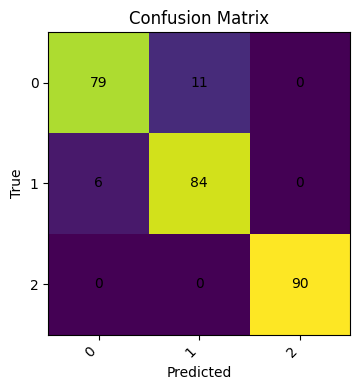

In [70]:
model.eval()

all_logits = []
all_probs  = []
all_preds  = []
all_true   = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        # yb may be tensor or Python int
        all_preds.append(torch.argmax(logits, dim=1).cpu())
        all_true.append(yb if isinstance(yb, torch.Tensor) else torch.tensor(yb))

# Flatten
logits = torch.cat(all_logits)
probs  = torch.cat(all_probs)
y_pred = torch.cat(all_preds)
y_true = torch.cat(all_true)

# ---- Overall accuracy ----
test_acc = (y_pred == y_true).float().mean().item()
print(f"\n✅ Test accuracy: {test_acc:.4f}")

#====================================================
#  Confusion Matrix
#====================================================
# Ensure class maps exist
try:
    idx_to_label
except NameError:
    # Recover from train_df if needed
    classes = sorted(train_df["label"].unique())
    idx_to_label = {i: c for i, c in enumerate(classes)}

NUM_CLASSES = len(idx_to_label)

cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

print("\n📋 Confusion matrix (rows=true, cols=pred):\n")
print(cm.numpy())

#=====================================================
#  Per-class metrics (precision, recall, F1)
#=====================================================

tp = torch.diag(cm).float()
fp = (cm.sum(0).float() - tp)
fn = (cm.sum(1).float() - tp)

prec = tp / torch.clamp(tp + fp, min=1.0)
rec  = tp / torch.clamp(tp + fn, min=1.0)
f1   = 2 * prec * rec / torch.clamp(prec + rec, min=1e-12)
macro_f1 = f1.mean().item()

print("\n📈 Per-class metrics:")
for i in range(NUM_CLASSES):
    name = str(idx_to_label[i])   # <-- ensure string
    print(f"{name:>12} | P:{prec[i]:.3f} R:{rec[i]:.3f} F1:{f1[i]:.3f}  Support:{cm[i].sum().item()}")


print(f"\n⭐ Macro-F1: {macro_f1:.3f}")

#=====================================================
#  Confusion matrix plot
#=====================================================
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm.numpy(), interpolation='nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([str(idx_to_label[i]) for i in range(NUM_CLASSES)], rotation=45, ha="right")
ax.set_yticklabels([str(idx_to_label[i]) for i in range(NUM_CLASSES)])


for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, int(cm[i, j].item()), ha="center", va="center")

plt.tight_layout()
plt.show()

# Plotting

# Feature mapping